Transformer Models: A collection of various transformer architectures, models, & their implementations-from-scratch (`PyTorch`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/transformers-from-scratch
---


In [1]:
%%capture
!pip install watermark
!pip install torchinfo
!pip install datasets


In [2]:
%load_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch


Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.10.0+cu128



# BERT: Fine-tuning for Extractive Question Answering
---

This notebook implements **BERT** (Bidirectional Encoder Representations from Transformers) **[1]** from scratch,
evolving directly from the Transformer Encoder in the previous *"Attention Is All You Need"* notebook.

The implementation has **two phases:**

1. **Phase 1 — Pre-training:** We train BERT with two self-supervised objectives:
   - **Masked Language Modeling (MLM):** Randomly mask 15% of tokens and predict them.
   - **Next Sentence Prediction (NSP):** Given two sentences, predict if sentence B actually follows sentence A.

2. **Phase 2 — Fine-tuning:** We take the pre-trained BERT and add a **span-prediction head** to fine-tune on
   **SQuAD v2.0** for extractive question answering. The model must predict the start and end positions of the
   answer within the context, or determine that the question is **unanswerable**.


<br>

## BERT: Pre-Training & Fine-Tuning
![BERT](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*5cQlEV_7WuzUfE1B__jR5Q.png)

<br>

### SQuAD v2.0: Extractive Question Answering

| Feature | SQuAD v1.1 | SQuAD v2.0 |
| :--- | :--- | :--- |
| **Answerable** | All questions have answers | ~50% are **unanswerable** |
| **Task** | Predict (start, end) span | Predict span **or** "no answer" |
| **Metric** | EM / F1 | EM / F1 (with no-answer handling) |

The input format is:

$$[\texttt{CLS}] \; \text{question} \; [\texttt{SEP}] \; \text{context} \; [\texttt{SEP}]$$

The model predicts two probability distributions over token positions — one for the **start** and one for the **end** of the answer span.
For unanswerable questions, both start and end point to the `[CLS]` token (position 0).

<br>

---

**REFERENCES:**

1. Devlin, Jacob, et al. ["BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding."](https://arxiv.org/abs/1810.04805) *NAACL*, 2019.
2. Rajpurkar, Pranav, et al. ["Know What You Don't Know: Unanswerable Questions for SQuAD."](https://arxiv.org/abs/1806.03822) *ACL*, 2018.
3. Vaswani, Ashish, et al. ["Attention is all you need."](https://arxiv.org/abs/1706.03762) *NeurIPS*, 2017.

---


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from torch.amp import GradScaler, autocast
from torchinfo import summary

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True


In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


---
# 0. Hyperparameters
---


In [5]:
##########################
### SETTINGS
##########################

RANDOM_SEED = 123
set_all_seeds(RANDOM_SEED)

# Vocabulary
VOCABULARY_SIZE = 10000

# BERT Architecture (BERT-Small for training feasibility)
D_MODEL = 768 # 256 # 768
N_LAYERS = 12 # 4 # 12
N_HEADS = 12 # 8 # 12
D_FF = 4 * D_MODEL # 4 * 768
DROPOUT = 0.1
MAX_LEN = 128

# Pre-training
PRETRAIN_EPOCHS = 10
PRETRAIN_BATCH_SIZE = 64
PRETRAIN_LR = 1e-4

# Fine-tuning
FINETUNE_EPOCHS = 10
FINETUNE_BATCH_SIZE = 32
FINETUNE_LR = 2e-5
PATIENCE = 3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


---
# 1. Data Preparation & Vocabulary

We build a single vocabulary from **WikiText-2** for pre-training,
then reuse it for SQuAD v2.0 fine-tuning.

---


In [6]:
# ==========================================
# 1a. Load Datasets
# ==========================================

# Pre-training corpus
wiki_dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

# Fine-tuning dataset (SQuAD v2.0)
squad_dataset = load_dataset("rajpurkar/squad_v2")

print(f"WikiText-2 samples - train: {len(wiki_dataset['train'])}, val: {len(wiki_dataset['validation'])}, test: {len(wiki_dataset['test'])}")
print(f"SQuAD v2.0 samples - train: {len(squad_dataset['train'])}, val: {len(squad_dataset['validation'])}")
print(f"\nSample SQuAD entry:")
sample = squad_dataset['train'][0]
print(f"  Question: {sample['question']}")
print(f"  Context:  {sample['context'][:150]}...")
print(f"  Answer:   {sample['answers']}")


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

...

squad_v2/train-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

squad_v2/validation-00000-of-00001.parqu(…):   0%|          | 0.00/1.35M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

WikiText-2 samples - train: 36718, val: 3760, test: 4358
SQuAD v2.0 samples - train: 130319, val: 11873

Sample SQuAD entry:
  Question: When did Beyonce start becoming popular?
  Context:  Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Bor...
  Answer:   {'text': ['in the late 1990s'], 'answer_start': [269]}


In [7]:
# ==========================================
# 1b. Tokenizer & Vocabulary
# ==========================================

def tokenizer(text):
    """Simple word-level tokenizer with punctuation splitting."""
    return re.findall(r"[\w']+|[.,!?;:\-]", text.lower())

# BERT Special Tokens
SPECIAL_TOKENS = ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
PAD_IDX, UNK_IDX, CLS_IDX, SEP_IDX, MASK_IDX = 0, 1, 2, 3, 4

# Build vocab from WikiText-2 (the pre-training corpus)
word_counts = Counter()
for item in wiki_dataset['train']:
    text = item['text'].strip()
    if len(text) > 0:
        word_counts.update(tokenizer(text))

# Build vocab dict
vocab = {word: i for i, word in enumerate(SPECIAL_TOKENS)}
for word, _ in word_counts.most_common(VOCABULARY_SIZE - len(SPECIAL_TOKENS)):
    if word not in vocab:
        vocab[word] = len(vocab)

inv_vocab = {v: k for k, v in vocab.items()}

ACTUAL_VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {ACTUAL_VOCAB_SIZE}")
print(f"Sample tokens: {list(vocab.keys())[:15]}")


Vocabulary size: 10000
Sample tokens: ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]', 'the', ',', '.', 'of', 'and', 'in', 'to', 'a', 'was', '-']


---
# 1. Pre-training Data Pipeline (MLM + NSP)

For **NSP**, we construct sentence pairs:
- 50% of the time, sentence B actually follows sentence A (`IsNext = 1`)
- 50% of the time, sentence B is a random sentence (`NotNext = 0`)

For **MLM**, we mask 15% of the input tokens in each pair:
- 80% → replaced with `[MASK]`
- 10% → replaced with a random token
- 10% → kept unchanged

---


In [8]:
# ==========================================
# 1c. Pre-training Dataset (MLM + NSP)
# ==========================================

def encode_sentence(text, max_len=None):
    """Tokenize and convert to indices."""
    tokens = tokenizer(text)
    if max_len is not None:
        tokens = tokens[:max_len]
    return [vocab.get(t, UNK_IDX) for t in tokens]


class BERTPretrainDataset(Dataset):
    """
    Constructs MLM + NSP training pairs from raw text.
    Each sample: ([CLS] sent_A [SEP] sent_B [SEP], segment_ids, mlm_labels, nsp_label)
    """
    def __init__(self, text_dataset, vocab, max_len=128, mlm_prob=0.15):
        super().__init__()
        self.max_len = max_len
        self.mlm_prob = mlm_prob
        self.vocab = vocab
        self.vocab_size = len(vocab)

        # Collect non-empty sentences
        self.sentences = []
        for item in text_dataset:
            text = item['text'].strip()
            if len(text) > 10:  # Skip very short/empty lines
                self.sentences.append(text)

        print(f"  PretrainDataset: {len(self.sentences)} sentences loaded.")

    def __len__(self):
        return len(self.sentences) - 1  # Need pairs

    def __getitem__(self, idx):
        # --- NSP: 50% real next, 50% random ---
        sent_a = encode_sentence(self.sentences[idx], max_len=self.max_len // 2 - 2)

        if random.random() > 0.5 and idx + 1 < len(self.sentences):
            sent_b = encode_sentence(self.sentences[idx + 1], max_len=self.max_len // 2 - 1)
            nsp_label = 1  # IsNext
        else:
            rand_idx = random.randint(0, len(self.sentences) - 1)
            sent_b = encode_sentence(self.sentences[rand_idx], max_len=self.max_len // 2 - 1)
            nsp_label = 0  # NotNext

        # --- Build BERT input: [CLS] A [SEP] B [SEP] ---
        tokens = [CLS_IDX] + sent_a + [SEP_IDX] + sent_b + [SEP_IDX]
        segment_ids = [0] * (len(sent_a) + 2) + [1] * (len(sent_b) + 1)

        # Truncate to max_len
        tokens = tokens[:self.max_len]
        segment_ids = segment_ids[:self.max_len]

        # --- MLM: Mask 15% of tokens (skip [CLS], [SEP], [PAD]) ---
        mlm_labels = [-100] * len(tokens)  # -100 = ignore in CrossEntropyLoss
        for i in range(len(tokens)):
            if tokens[i] in (CLS_IDX, SEP_IDX, PAD_IDX):
                continue
            if random.random() < self.mlm_prob:
                mlm_labels[i] = tokens[i]  # Store original for loss
                r = random.random()
                if r < 0.8:
                    tokens[i] = MASK_IDX       # 80%: [MASK]
                elif r < 0.9:
                    tokens[i] = random.randint(len(SPECIAL_TOKENS), self.vocab_size - 1)  # 10%: random
                # else: 10%: keep original (already set)

        return (
            torch.tensor(tokens, dtype=torch.long),
            torch.tensor(segment_ids, dtype=torch.long),
            torch.tensor(mlm_labels, dtype=torch.long),
            torch.tensor(nsp_label, dtype=torch.long),
        )


def pretrain_collate_fn(batch):
    """Pad all tensors in the batch to the same length."""
    tokens, segments, mlm_labels, nsp_labels = zip(*batch)

    tokens = pad_sequence(tokens, batch_first=True, padding_value=PAD_IDX)
    segments = pad_sequence(segments, batch_first=True, padding_value=0)
    mlm_labels = pad_sequence(mlm_labels, batch_first=True, padding_value=-100)
    nsp_labels = torch.stack(nsp_labels)

    return tokens, segments, mlm_labels, nsp_labels


In [9]:
# Build Pre-training DataLoaders
pretrain_train_dataset = BERTPretrainDataset(wiki_dataset['train'], vocab, max_len=MAX_LEN)
pretrain_val_dataset   = BERTPretrainDataset(wiki_dataset['validation'], vocab, max_len=MAX_LEN)

pretrain_train_loader = DataLoader(
    pretrain_train_dataset, batch_size=PRETRAIN_BATCH_SIZE,
    shuffle=True, collate_fn=pretrain_collate_fn, num_workers=0
)
pretrain_val_loader = DataLoader(
    pretrain_val_dataset, batch_size=PRETRAIN_BATCH_SIZE,
    shuffle=False, collate_fn=pretrain_collate_fn, num_workers=0
)

# Quick sanity check
sample = next(iter(pretrain_train_loader))
print(f"\nBatch shapes: \n tokens: {sample[0].shape},\n segments: {sample[1].shape},\n "
      f"mlm_labels: {sample[2].shape},\n nsp_labels: {sample[3].shape}")
print(f"\nTrain batches: {len(pretrain_train_loader)}, Val batches: {len(pretrain_val_loader)}")


  PretrainDataset: 23547 sentences loaded.
  PretrainDataset: 2454 sentences loaded.

Batch shapes: 
 tokens: torch.Size([64, 128]),
 segments: torch.Size([64, 128]),
 mlm_labels: torch.Size([64, 128]),
 nsp_labels: torch.Size([64])

Train batches: 368, Val batches: 39


---
# 2. BERT Model Architecture

We reuse the core `MultiHeadAttention` and `EncoderLayer` from the Transformer notebook,
but with BERT-specific modifications:

1. **Learned Positional Embeddings** (not sinusoidal)
2. **Segment (Token Type) Embeddings** for NSP
3. **GELU activation** in the Feed-Forward layers
4. **Two output heads:** MLM head + NSP head

---


In [10]:
# ==========================================
# 2a. Multi-Head Attention (from Transformer notebook)
# ==========================================

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc_out = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]

        Q = self.w_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        energy = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float('-inf'))

        attention = torch.softmax(energy, dim=-1)
        x = torch.matmul(self.dropout(attention), V)

        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.fc_out(x)


In [11]:
# ==========================================
# 2b. Feed-Forward Network (GELU for BERT)
# ==========================================

class PositionwiseFeedForward(nn.Module):
    """BERT uses GELU activation instead of ReLU."""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


In [12]:
# ==========================================
# 2c. Encoder Layer (reused from Transformer)
# ==========================================

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        # Post-LN (original BERT): Attn → Residual → LayerNorm
        _src = self.self_attn(src, src, src, src_mask)
        src = self.norm1(src + self.dropout(_src))

        _src = self.feed_forward(src)
        src = self.norm2(src + self.dropout(_src))
        return src


In [13]:
# ==========================================
# 2d. BERT Model
# ==========================================

class BERT(nn.Module):
    """
    BERT: Bidirectional Encoder Representations from Transformers.

    Key differences from Transformer encoder:
    - Learned positional embeddings (not sinusoidal)
    - Segment embeddings for NSP (sentence A=0, B=1)
    - [CLS] token pooling for classification
    - Two pre-training heads: MLM + NSP
    """
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff,
                 dropout, max_len, pad_idx, device):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model
        self.device = device

        # --- BERT Embeddings (Learned, not sinusoidal) ---
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.segment_embedding = nn.Embedding(2, d_model)  # 0 = sent A, 1 = sent B
        self.embed_norm = nn.LayerNorm(d_model)
        self.embed_dropout = nn.Dropout(dropout)

        # --- Encoder Stack ---
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        # --- Pre-training Heads ---
        # MLM Head: predict masked tokens
        self.mlm_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Linear(d_model, vocab_size)
        )

        # NSP Head: binary classification from [CLS]
        self.nsp_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.Tanh(),
            nn.Linear(d_model, 2)
        )

    def make_pad_mask(self, input_ids):
        """Padding mask: 1 for real tokens, 0 for [PAD]."""
        return (input_ids != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def get_embeddings(self, input_ids, segment_ids):
        """BERT embedding = token + position + segment, then LayerNorm + Dropout."""
        seq_len = input_ids.size(1)
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)

        tok_emb = self.token_embedding(input_ids) * math.sqrt(self.d_model)
        pos_emb = self.position_embedding(positions)
        seg_emb = self.segment_embedding(segment_ids)

        return self.embed_dropout(self.embed_norm(tok_emb + pos_emb + seg_emb))

    def encode(self, input_ids, segment_ids):
        """Run the encoder stack. Returns the full sequence of hidden states."""
        mask = self.make_pad_mask(input_ids)
        x = self.get_embeddings(input_ids, segment_ids)

        for layer in self.encoder_layers:
            x = layer(x, mask)

        return x  # [batch, seq_len, d_model]

    def forward(self, input_ids, segment_ids):
        """
        Pre-training forward pass.
        Returns: mlm_logits [batch, seq_len, vocab_size], nsp_logits [batch, 2]
        """
        hidden = self.encode(input_ids, segment_ids)

        mlm_logits = self.mlm_head(hidden)
        cls_hidden = hidden[:, 0, :]  # [CLS] is always position 0
        nsp_logits = self.nsp_head(cls_hidden)

        return mlm_logits, nsp_logits


In [14]:
def count_parameters(model):
    """Parameter breakdown for BERT."""
    def count(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

    emb = count(model.token_embedding) + count(model.position_embedding) + count(model.segment_embedding)
    enc = count(model.encoder_layers)
    mlm = count(model.mlm_head)
    nsp = count(model.nsp_head)
    total = count(model)

    print(f"{'Component':<25} | {'Parameters':<12}")
    print("-" * 42)
    print(f"{'Embeddings (tok+pos+seg)':<25} | {emb:,}")
    print(f"{'Encoder Stack (N Layers)':<25} | {enc:,}")
    print(f"{'MLM Head':<25} | {mlm:,}")
    print(f"{'NSP Head':<25} | {nsp:,}")
    print("-" * 42)
    print(f"{'TOTAL TRAINABLE':<25} | {total:,}")


---
# 3. Phase 1 — Pre-training (MLM + NSP)

---


In [15]:
# ==========================================
# 3a. Pre-training Evaluation + Training Loop
# ==========================================

def evaluate_pretrain(model, data_loader, mlm_criterion, nsp_criterion, device):
    """
    Evaluate BERT pre-training on a validation set.
    Returns avg MLM loss, avg NSP loss, MLM accuracy, NSP accuracy.
    """
    model.eval()
    total_mlm_loss, total_nsp_loss = 0.0, 0.0
    mlm_correct, mlm_total = 0, 0
    nsp_correct, nsp_total = 0, 0

    with torch.no_grad():
        for tokens, segments, mlm_labels, nsp_labels in data_loader:
            tokens = tokens.to(device)
            segments = segments.to(device)
            mlm_labels = mlm_labels.to(device)
            nsp_labels = nsp_labels.to(device)

            mlm_logits, nsp_logits = model(tokens, segments)

            mlm_loss = mlm_criterion(
                mlm_logits.view(-1, mlm_logits.size(-1)),
                mlm_labels.view(-1)
            )
            nsp_loss = nsp_criterion(nsp_logits, nsp_labels)

            total_mlm_loss += mlm_loss.item()
            total_nsp_loss += nsp_loss.item()

            # MLM accuracy (only masked positions)
            mask_pos = mlm_labels.view(-1) != -100
            if mask_pos.any():
                mlm_preds = mlm_logits.view(-1, mlm_logits.size(-1)).argmax(dim=-1)
                mlm_correct += (mlm_preds[mask_pos] == mlm_labels.view(-1)[mask_pos]).sum().item()
                mlm_total += mask_pos.sum().item()

            # NSP accuracy
            nsp_preds = nsp_logits.argmax(dim=-1)
            nsp_correct += (nsp_preds == nsp_labels).sum().item()
            nsp_total += nsp_labels.size(0)

    n = len(data_loader)
    return (
        total_mlm_loss / n,
        total_nsp_loss / n,
        mlm_correct / max(mlm_total, 1),
        nsp_correct / max(nsp_total, 1),
    )


def pretrain_bert(model, train_loader, val_loader, num_epochs, lr, device, patience=5):
    """
    Robust BERT pre-training loop with Mixed Precision, Validation,
    Early Stopping, and Best-Model Checkpointing.
    (Mirrors train_transformer structure from the Transformer notebook.)
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=0.01)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=num_epochs
    )

    mlm_criterion = nn.CrossEntropyLoss(ignore_index=-100)
    nsp_criterion = nn.CrossEntropyLoss()

    use_amp = (device.type == 'cuda')
    scaler = GradScaler('cuda', enabled=use_amp)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    start_time = time.time()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_mlm_loss': [], 'val_mlm_loss': [],
        'train_nsp_loss': [], 'val_nsp_loss': [],
        'train_mlm_acc': [], 'val_mlm_acc': [],
        'train_nsp_acc': [], 'val_nsp_acc': [],
        'lrs': []
    }

    print(f"Starting BERT pre-training on {device}...")
    print(f"Epochs: {num_epochs} | Batches/epoch: {len(train_loader)} | LR: {lr} | Patience: {patience}")
    print("-" * 110)

    for epoch in range(num_epochs):
        model.train()
        epoch_mlm_loss, epoch_nsp_loss = 0.0, 0.0
        epoch_mlm_correct, epoch_mlm_total = 0, 0
        epoch_nsp_correct, epoch_nsp_total = 0, 0
        train_tokens = 0

        for tokens, segments, mlm_labels, nsp_labels in train_loader:
            tokens = tokens.to(device, non_blocking=True)
            segments = segments.to(device, non_blocking=True)
            mlm_labels = mlm_labels.to(device, non_blocking=True)
            nsp_labels = nsp_labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=use_amp):
                mlm_logits, nsp_logits = model(tokens, segments)

                # MLM loss: flatten [batch*seq_len, vocab_size] vs [batch*seq_len]
                mlm_loss = mlm_criterion(
                    mlm_logits.view(-1, mlm_logits.size(-1)),
                    mlm_labels.view(-1)
                )

                # NSP loss
                nsp_loss = nsp_criterion(nsp_logits, nsp_labels)
                loss = mlm_loss + nsp_loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            # --- Accuracy tracking (on masked positions only for MLM) ---
            with torch.no_grad():
                mask_pos = mlm_labels.view(-1) != -100
                if mask_pos.any():
                    mlm_preds = mlm_logits.view(-1, mlm_logits.size(-1)).argmax(dim=-1)
                    epoch_mlm_correct += (mlm_preds[mask_pos] == mlm_labels.view(-1)[mask_pos]).sum().item()
                    epoch_mlm_total += mask_pos.sum().item()

                nsp_preds = nsp_logits.argmax(dim=-1)
                epoch_nsp_correct += (nsp_preds == nsp_labels).sum().item()
                epoch_nsp_total += nsp_labels.size(0)

            epoch_mlm_loss += mlm_loss.item()
            epoch_nsp_loss += nsp_loss.item()
            train_tokens += (tokens != PAD_IDX).sum().item()

        # --- Epoch Train Stats ---
        n_batches = len(train_loader)
        t_mlm = epoch_mlm_loss / n_batches
        t_nsp = epoch_nsp_loss / n_batches
        t_mlm_acc = epoch_mlm_correct / max(epoch_mlm_total, 1)
        t_nsp_acc = epoch_nsp_correct / max(epoch_nsp_total, 1)
        t_loss = t_mlm + t_nsp

        # --- Epoch Validation ---
        v_mlm, v_nsp, v_mlm_acc, v_nsp_acc = evaluate_pretrain(
            model, val_loader, mlm_criterion, nsp_criterion, device
        )
        v_loss = v_mlm + v_nsp

        # --- Early Stopping & Checkpoint ---
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), 'bert_pretrained_squadv2.pth')
            epochs_no_improve = 0
            status_msg = " * (Saved Best)"
        else:
            epochs_no_improve += 1
            status_msg = f" (No improve: {epochs_no_improve}/{patience})"

        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - start_time
        tok_per_sec = train_tokens / elapsed

        # --- Update History ---
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_mlm_loss'].append(t_mlm)
        history['val_mlm_loss'].append(v_mlm)
        history['train_nsp_loss'].append(t_nsp)
        history['val_nsp_loss'].append(v_nsp)
        history['train_mlm_acc'].append(t_mlm_acc)
        history['val_mlm_acc'].append(v_mlm_acc)
        history['train_nsp_acc'].append(t_nsp_acc)
        history['val_nsp_acc'].append(v_nsp_acc)
        history['lrs'].append(current_lr)

        print(f"Epoch {epoch+1:03d}/{num_epochs:03d} | "
              f"Loss (T/V): {t_loss:.4f} / {v_loss:.4f} | "
              f"MLM Acc (T/V): {t_mlm_acc*100:.1f}% / {v_mlm_acc*100:.1f}% | "
              f"NSP Acc (T/V): {t_nsp_acc*100:.1f}% / {v_nsp_acc*100:.1f}% | "
              f"tok/s: {tok_per_sec:07.0f} | "
              f"LR: {current_lr:.6f}{status_msg}")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered.")
            break

    print(f'\nDone! Total Time: {(time.time() - start_time) / 60:.2f} min')
    model.load_state_dict(torch.load('bert_pretrained_squadv2.pth'))
    return history


In [16]:
# ==========================================
# 3b. Initialize & Pre-train BERT
# ==========================================

set_all_seeds(RANDOM_SEED)

bert_model = BERT(
    vocab_size=ACTUAL_VOCAB_SIZE,
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    d_ff=D_FF,
    dropout=DROPOUT,
    max_len=MAX_LEN,
    pad_idx=PAD_IDX,
    device=DEVICE
).to(DEVICE)

# Xavier init (same as Transformer notebook)
def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

bert_model.apply(initialize_weights)
count_parameters(bert_model)


Component                 | Parameters  
------------------------------------------
Embeddings (tok+pos+seg)  | 7,779,840
Encoder Stack (N Layers)  | 85,054,464
MLM Head                  | 8,282,128
NSP Head                  | 592,130
------------------------------------------
TOTAL TRAINABLE           | 101,710,098


In [17]:
# Run Pre-training
pretrain_history = pretrain_bert(
    model=bert_model,
    train_loader=pretrain_train_loader,
    val_loader=pretrain_val_loader,
    num_epochs=PRETRAIN_EPOCHS,
    lr=PRETRAIN_LR,
    device=DEVICE,
    patience=PATIENCE
)


Starting BERT pre-training on cuda...
Epochs: 10 | Batches/epoch: 368 | LR: 0.0001 | Patience: 3
--------------------------------------------------------------------------------------------------------------
Epoch 001/010 | Loss (T/V): 8.3554 / 6.9943 | MLM Acc (T/V): 8.1% / 10.4% | NSP Acc (T/V): 50.5% / 52.5% | tok/s: 0009864 | LR: 0.000028 * (Saved Best)
Epoch 002/010 | Loss (T/V): 7.1343 / 6.9441 | MLM Acc (T/V): 8.4% / 10.4% | NSP Acc (T/V): 50.8% / 51.3% | tok/s: 0004800 | LR: 0.000076 * (Saved Best)
Epoch 003/010 | Loss (T/V): 7.1399 / 6.9789 | MLM Acc (T/V): 8.3% / 10.1% | NSP Acc (T/V): 50.2% / 48.4% | tok/s: 0003170 | LR: 0.000100 (No improve: 1/3)
Epoch 004/010 | Loss (T/V): 7.1337 / 6.9430 | MLM Acc (T/V): 8.4% / 10.5% | NSP Acc (T/V): 50.0% / 50.3% | tok/s: 0002379 | LR: 0.000095 * (Saved Best)
Epoch 005/010 | Loss (T/V): 7.0964 / 6.9116 | MLM Acc (T/V): 8.4% / 10.8% | NSP Acc (T/V): 49.9% / 50.3% | tok/s: 0001900 | LR: 0.000081 * (Saved Best)
Epoch 006/010 | Loss (T/V): 7

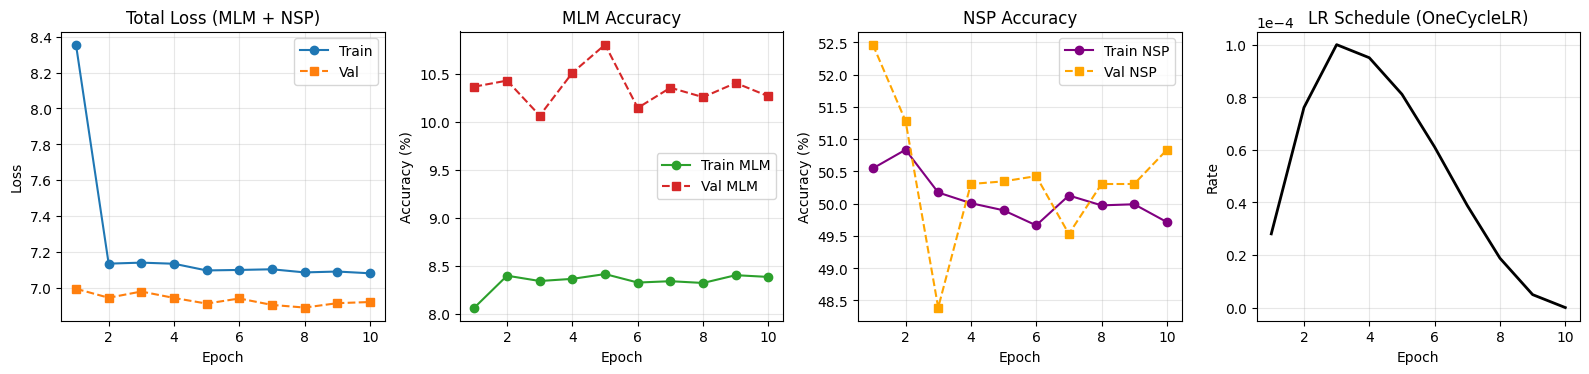

In [18]:
# ==========================================
# 3c. Plot Pre-training Curves
# ==========================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
epochs = range(1, len(pretrain_history['train_loss']) + 1)

# 1. Total Loss (Train vs Val)
axes[0].plot(epochs, pretrain_history['train_loss'], 'o-', label='Train', color='#1f77b4')
axes[0].plot(epochs, pretrain_history['val_loss'], 's--', label='Val', color='#ff7f0e')
axes[0].set_title('Total Loss (MLM + NSP)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. MLM Accuracy (Train vs Val)
axes[1].plot(epochs, [a*100 for a in pretrain_history['train_mlm_acc']], 'o-', label='Train MLM', color='#2ca02c')
axes[1].plot(epochs, [a*100 for a in pretrain_history['val_mlm_acc']], 's--', label='Val MLM', color='#d62728')
axes[1].set_title('MLM Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. NSP Accuracy (Train vs Val)
axes[2].plot(epochs, [a*100 for a in pretrain_history['train_nsp_acc']], 'o-', label='Train NSP', color='purple')
axes[2].plot(epochs, [a*100 for a in pretrain_history['val_nsp_acc']], 's--', label='Val NSP', color='orange')
axes[2].set_title('NSP Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 4. Learning Rate Schedule
axes[3].plot(epochs, pretrain_history['lrs'], label='LR', color='black', linewidth=2)
axes[3].set_title('LR Schedule (OneCycleLR)')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Rate')
axes[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
# 4. Phase 2 — Fine-tuning on SQuAD v2.0 (Extractive QA)

We take the pre-trained BERT encoder and add a **span prediction head** that outputs
start and end logits for every token position.

For **unanswerable** questions (SQuAD v2.0), both start and end targets point to
position 0 (`[CLS]`), and we use a null-score threshold at inference time.

Input: `[CLS] question [SEP] context [SEP]`

---


In [19]:
# ==========================================
# 4a. SQuAD v2.0 Dataset
# ==========================================

class SQuADDataset(Dataset):
    """
    Wraps SQuAD v2.0 for BERT extractive QA.
    Format: [CLS] question [SEP] context [SEP]
    Targets: start_position, end_position (0,0 for unanswerable)
    """
    def __init__(self, hf_dataset, vocab, max_len=384):
        self.vocab = vocab
        self.max_len = max_len
        self.samples = []

        skipped = 0
        for item in hf_dataset:
            question = item['question']
            context = item['context']
            answers = item['answers']

            # Tokenize question and context
            q_tokens = tokenizer(question)
            c_tokens = tokenizer(context)

            # Build character-to-token mapping for the context
            # We need this to convert character-level answer_start to token-level
            c_text_lower = context.lower()
            char_to_tok = [None] * len(c_text_lower)
            tok_spans = []
            pos = 0
            for ti, tok in enumerate(c_tokens):
                start = c_text_lower.find(tok, pos)
                if start == -1:
                    start = pos
                end = start + len(tok)
                tok_spans.append((start, end))
                for ci in range(start, min(end, len(c_text_lower))):
                    char_to_tok[ci] = ti
                pos = end

            # Truncate to fit: [CLS] question [SEP] context [SEP]
            max_q_len = min(len(q_tokens), 64)
            max_c_len = self.max_len - max_q_len - 3  # 3 special tokens
            if max_c_len <= 0:
                skipped += 1
                continue

            q_tokens = q_tokens[:max_q_len]
            c_tokens_trunc = c_tokens[:max_c_len]

            # Encode
            q_ids = [vocab.get(t, UNK_IDX) for t in q_tokens]
            c_ids = [vocab.get(t, UNK_IDX) for t in c_tokens_trunc]

            # [CLS] question [SEP] context [SEP]
            input_ids = [CLS_IDX] + q_ids + [SEP_IDX] + c_ids + [SEP_IDX]
            segment_ids = [0] * (len(q_ids) + 2) + [1] * (len(c_ids) + 1)

            # Context starts at this offset in input_ids
            context_offset = len(q_ids) + 2  # after [CLS] + question + [SEP]

            # Determine answer positions
            if len(answers['answer_start']) == 0:
                # Unanswerable → point to [CLS] (position 0)
                start_pos = 0
                end_pos = 0
                is_impossible = True
            else:
                ans_char_start = answers['answer_start'][0]
                ans_text = answers['text'][0]
                ans_char_end = ans_char_start + len(ans_text) - 1

                # Map character positions to token positions
                if ans_char_start < len(char_to_tok) and char_to_tok[ans_char_start] is not None:
                    tok_start = char_to_tok[ans_char_start]
                else:
                    skipped += 1
                    continue

                ans_char_end_clamped = min(ans_char_end, len(char_to_tok) - 1)
                tok_end = char_to_tok[ans_char_end_clamped] if char_to_tok[ans_char_end_clamped] is not None else tok_start

                # Check if answer fits within truncated context
                if tok_start >= max_c_len or tok_end >= max_c_len:
                    skipped += 1
                    continue

                start_pos = context_offset + tok_start
                end_pos = context_offset + tok_end
                is_impossible = False

            self.samples.append({
                'input_ids': torch.tensor(input_ids, dtype=torch.long),
                'segment_ids': torch.tensor(segment_ids, dtype=torch.long),
                'start_pos': torch.tensor(start_pos, dtype=torch.long),
                'end_pos': torch.tensor(end_pos, dtype=torch.long),
                'is_impossible': is_impossible,
                'context_tokens': c_tokens_trunc,
                'context_offset': context_offset,
                'question': question,
                'context': context,
                'gold_text': answers['text'][0] if len(answers['text']) > 0 else '',
            })

        print(f"  SQuADDataset: {len(self.samples)} samples loaded, {skipped} skipped.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return s['input_ids'], s['segment_ids'], s['start_pos'], s['end_pos']


def squad_collate_fn(batch):
    input_ids, segment_ids, starts, ends = zip(*batch)
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=PAD_IDX)
    segment_ids = pad_sequence(segment_ids, batch_first=True, padding_value=0)
    starts = torch.stack(starts)
    ends = torch.stack(ends)
    return input_ids, segment_ids, starts, ends


In [20]:
# Build SQuAD DataLoaders
# Use a subset for training feasibility with from-scratch BERT
SQUAD_MAX_LEN = min(MAX_LEN, 384)
SQUAD_TRAIN_SIZE = 20000  # Subset for feasibility
SQUAD_VAL_SIZE = 3000

squad_train_subset = squad_dataset['train'].select(range(min(SQUAD_TRAIN_SIZE, len(squad_dataset['train']))))
squad_val_subset = squad_dataset['validation'].select(range(min(SQUAD_VAL_SIZE, len(squad_dataset['validation']))))

squad_train_ds = SQuADDataset(squad_train_subset, vocab, max_len=SQUAD_MAX_LEN)
squad_val_ds = SQuADDataset(squad_val_subset, vocab, max_len=SQUAD_MAX_LEN)

squad_train_loader = DataLoader(
    squad_train_ds, batch_size=FINETUNE_BATCH_SIZE,
    shuffle=True, collate_fn=squad_collate_fn
)
squad_val_loader = DataLoader(
    squad_val_ds, batch_size=FINETUNE_BATCH_SIZE,
    shuffle=False, collate_fn=squad_collate_fn
)

print(f"SQuAD Train batches: {len(squad_train_loader)}, Val batches: {len(squad_val_loader)}")

# Sanity check
sample_batch = next(iter(squad_train_loader))
print(f"Batch shapes — input_ids: {sample_batch[0].shape}, segments: {sample_batch[1].shape}, "
      f"starts: {sample_batch[2].shape}, ends: {sample_batch[3].shape}")


  SQuADDataset: 18469 samples loaded, 1531 skipped.
  SQuADDataset: 2853 samples loaded, 147 skipped.
SQuAD Train batches: 578, Val batches: 90
Batch shapes — input_ids: torch.Size([32, 128]), segments: torch.Size([32, 128]), starts: torch.Size([32]), ends: torch.Size([32])


In [21]:
# ==========================================
# 4b. BERT QA Head (Fine-tuning wrapper)
# ==========================================

class BERTForQA(nn.Module):
    """
    BERT for Extractive Question Answering.

    Takes a pre-trained BERT encoder and adds a span prediction head.
    For each token position, outputs start_logit and end_logit.
    For unanswerable questions, the model should predict (0, 0) = [CLS] position.
    """
    def __init__(self, bert_model, d_model, dropout=0.1):
        super().__init__()
        self.bert = bert_model
        self.qa_dropout = nn.Dropout(dropout)
        # Single linear layer → 2 outputs (start_logit, end_logit) per token
        self.qa_outputs = nn.Linear(d_model, 2)

    def forward(self, input_ids, segment_ids):
        # Get encoder hidden states
        hidden = self.bert.encode(input_ids, segment_ids)  # [batch, seq_len, d_model]
        hidden = self.qa_dropout(hidden)

        logits = self.qa_outputs(hidden)  # [batch, seq_len, 2]
        start_logits = logits[:, :, 0]    # [batch, seq_len]
        end_logits = logits[:, :, 1]      # [batch, seq_len]

        return start_logits, end_logits


In [22]:
# ==========================================
# 4c. SQuAD Metrics: Exact Match & Token-level F1
# ==========================================

def normalize_answer(text):
    """Normalize answer text for comparison (lowercase, strip punctuation/articles)."""
    import string
    text = text.lower().strip()
    # Remove punctuation
    text = ''.join(c for c in text if c not in string.punctuation)
    # Remove articles
    for article in ['a ', 'an ', 'the ']:
        if text.startswith(article):
            text = text[len(article):]
    # Collapse whitespace
    text = ' '.join(text.split())
    return text


def compute_em(pred_text, gold_text):
    """Exact Match: 1 if normalized prediction == normalized gold, else 0."""
    return float(normalize_answer(pred_text) == normalize_answer(gold_text))


def compute_token_f1(pred_text, gold_text):
    """Token-level F1 between prediction and gold answer."""
    pred_tokens = normalize_answer(pred_text).split()
    gold_tokens = normalize_answer(gold_text).split()

    if not gold_tokens and not pred_tokens:
        return 1.0  # Both empty → correct "no answer"
    if not gold_tokens or not pred_tokens:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    n_common = sum(common.values())

    if n_common == 0:
        return 0.0

    precision = n_common / len(pred_tokens)
    recall = n_common / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)


In [23]:
# ==========================================
# 4d. QA Evaluation & Training Loop
# ==========================================

def evaluate_qa(model, data_loader, criterion, device):
    """Evaluate QA model on validation set. Returns avg loss."""
    model.eval()
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for input_ids, segment_ids, starts, ends in data_loader:
            input_ids = input_ids.to(device)
            segment_ids = segment_ids.to(device)
            starts = starts.to(device)
            ends = ends.to(device)

            start_logits, end_logits = model(input_ids, segment_ids)

            # Clamp targets to valid range
            seq_len = start_logits.size(1)
            starts = starts.clamp(0, seq_len - 1)
            ends = ends.clamp(0, seq_len - 1)

            loss = criterion(start_logits, starts) + criterion(end_logits, ends)
            total_loss += loss.item()
            n_batches += 1

    return total_loss / max(n_batches, 1)


def evaluate_qa_metrics(model, dataset, device, null_threshold=0.0):
    """
    Compute EM and F1 on the dataset by extracting predicted spans.
    For unanswerable questions: if best start/end is (0,0) → predict empty string.
    """
    model.eval()
    em_scores, f1_scores = [], []
    n_impossible_correct = 0
    n_impossible_total = 0

    for i in range(len(dataset)):
        s = dataset.samples[i]
        input_ids = s['input_ids'].unsqueeze(0).to(device)
        segment_ids = s['segment_ids'].unsqueeze(0).to(device)

        with torch.no_grad():
            start_logits, end_logits = model(input_ids, segment_ids)

        start_logits = start_logits.squeeze(0)
        end_logits = end_logits.squeeze(0)

        # Get best start/end positions
        # Constrain: answer must be within context and end >= start
        context_offset = s['context_offset']
        seq_len = start_logits.size(0)

        # Null score = score of [CLS] (position 0) for both start and end
        null_score = start_logits[0].item() + end_logits[0].item()

        # Best span score within context
        best_score = float('-inf')
        best_start, best_end = 0, 0

        for si in range(context_offset, seq_len):
            for ei in range(si, min(si + 30, seq_len)):  # max answer length = 30 tokens
                score = start_logits[si].item() + end_logits[ei].item()
                if score > best_score:
                    best_score = score
                    best_start = si
                    best_end = ei

        # Decide: answerable or not
        if null_score - null_threshold > best_score:
            pred_text = ''  # Predict unanswerable
        else:
            # Extract tokens from context
            tok_start = best_start - context_offset
            tok_end = best_end - context_offset
            c_tokens = s['context_tokens']
            if 0 <= tok_start < len(c_tokens) and 0 <= tok_end < len(c_tokens):
                pred_text = ' '.join(c_tokens[tok_start:tok_end + 1])
            else:
                pred_text = ''

        gold_text = s['gold_text']

        # Track impossible question accuracy
        if s['is_impossible']:
            n_impossible_total += 1
            if pred_text == '':
                n_impossible_correct += 1

        em_scores.append(compute_em(pred_text, gold_text))
        f1_scores.append(compute_token_f1(pred_text, gold_text))

    avg_em = np.mean(em_scores) if em_scores else 0.0
    avg_f1 = np.mean(f1_scores) if f1_scores else 0.0
    impossible_acc = n_impossible_correct / max(n_impossible_total, 1)

    return avg_em, avg_f1, impossible_acc


def finetune_qa(model, train_loader, val_loader, val_dataset, num_epochs, lr, device, patience=3):
    """
    Fine-tune BERT for extractive QA on SQuAD v2.0.
    Mirrors the train_transformer / finetune_bert loop structure.
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=num_epochs
    )
    criterion = nn.CrossEntropyLoss()

    use_amp = (device.type == 'cuda')
    scaler = GradScaler('cuda', enabled=use_amp)

    history = {'train_loss': [], 'val_loss': [], 'val_em': [], 'val_f1': [], 'lrs': []}
    best_val_f1 = 0.0
    epochs_no_improve = 0
    start_time = time.time()

    print(f"Fine-tuning BERT for QA on SQuAD v2.0 ({device})...")
    print(f"Epochs: {num_epochs} | LR: {lr} | Patience: {patience}")
    print("-" * 100)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for input_ids, segment_ids, starts, ends in train_loader:
            input_ids = input_ids.to(device, non_blocking=True)
            segment_ids = segment_ids.to(device, non_blocking=True)
            starts = starts.to(device, non_blocking=True)
            ends = ends.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=use_amp):
                start_logits, end_logits = model(input_ids, segment_ids)

                # Clamp targets to valid sequence length
                seq_len = start_logits.size(1)
                starts = starts.clamp(0, seq_len - 1)
                ends = ends.clamp(0, seq_len - 1)

                loss = criterion(start_logits, starts) + criterion(end_logits, ends)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_loss += loss.item()

        # --- Epoch Evaluation ---
        avg_train_loss = train_loss / len(train_loader)
        val_loss = evaluate_qa(model, val_loader, criterion, device)

        # Compute EM/F1 on a subset for speed
        eval_size = min(500, len(val_dataset))
        val_em, val_f1, imp_acc = evaluate_qa_metrics(model, val_dataset, device)

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_em'].append(val_em)
        history['val_f1'].append(val_f1)
        history['lrs'].append(current_lr)

        # Early stopping on F1
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_bert_squad.pth')
            epochs_no_improve = 0
            status = " * (Saved Best)"
        else:
            epochs_no_improve += 1
            status = f" (No improve: {epochs_no_improve}/{patience})"

        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1:02d}/{num_epochs} | "
              f"Loss (T/V): {avg_train_loss:.4f} / {val_loss:.4f} | "
              f"EM: {val_em*100:.2f}% | F1: {val_f1*100:.2f}% | "
              f"NoAns Acc: {imp_acc*100:.1f}% | "
              f"LR: {current_lr:.2e} | "
              f"Time: {elapsed/60:.1f}min{status}")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered.")
            break

    print(f"\nFine-tuning complete! Total time: {(time.time()-start_time)/60:.1f} min")
    print(f"Best Val F1: {best_val_f1*100:.2f}%")
    model.load_state_dict(torch.load('best_bert_squad.pth'))
    return history


In [24]:
# ==========================================
# 4e. Initialize & Fine-tune
# ==========================================

set_all_seeds(RANDOM_SEED)

# Load pre-trained weights
bert_model.load_state_dict(torch.load('bert_pretrained_squadv2.pth', map_location=DEVICE))

# Wrap with QA head
qa_model = BERTForQA(
    bert_model=bert_model,
    d_model=D_MODEL,
    dropout=DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in qa_model.parameters() if p.requires_grad)
qa_head_params = sum(p.numel() for p in qa_model.qa_outputs.parameters())
print(f"Total parameters: {total_params:,}")
print(f"QA head parameters: {qa_head_params:,} (added on top of pre-trained BERT)")


Total parameters: 101,711,636
QA head parameters: 1,538 (added on top of pre-trained BERT)


In [25]:
# Run Fine-tuning
qa_history = finetune_qa(
    qa_model, squad_train_loader, squad_val_loader, squad_val_ds,
    num_epochs=FINETUNE_EPOCHS,
    lr=FINETUNE_LR,
    device=DEVICE,
    patience=4 #PATIENCE
)


Fine-tuning BERT for QA on SQuAD v2.0 (cuda)...
Epochs: 10 | LR: 2e-05 | Patience: 4
----------------------------------------------------------------------------------------------------
Epoch 01/10 | Loss (T/V): 9.7698 / 9.6999 | EM: 51.81% | F1: 51.81% | NoAns Acc: 100.0% | LR: 5.61e-06 | Time: 7.1min * (Saved Best)
Epoch 02/10 | Loss (T/V): 9.3883 / 6.1491 | EM: 51.77% | F1: 51.77% | NoAns Acc: 99.9% | LR: 1.52e-05 | Time: 14.2min (No improve: 1/4)
Epoch 03/10 | Loss (T/V): 7.1483 / 5.5604 | EM: 51.81% | F1: 51.81% | NoAns Acc: 100.0% | LR: 2.00e-05 | Time: 21.3min (No improve: 2/4)
Epoch 04/10 | Loss (T/V): 6.0251 / 10.3555 | EM: 14.62% | F1: 15.75% | NoAns Acc: 26.8% | LR: 1.90e-05 | Time: 28.4min (No improve: 3/4)
Epoch 05/10 | Loss (T/V): 5.7116 / 8.6913 | EM: 21.66% | F1: 22.81% | NoAns Acc: 40.3% | LR: 1.62e-05 | Time: 35.5min (No improve: 4/4)

Early stopping triggered.

Fine-tuning complete! Total time: 35.5 min
Best Val F1: 51.81%


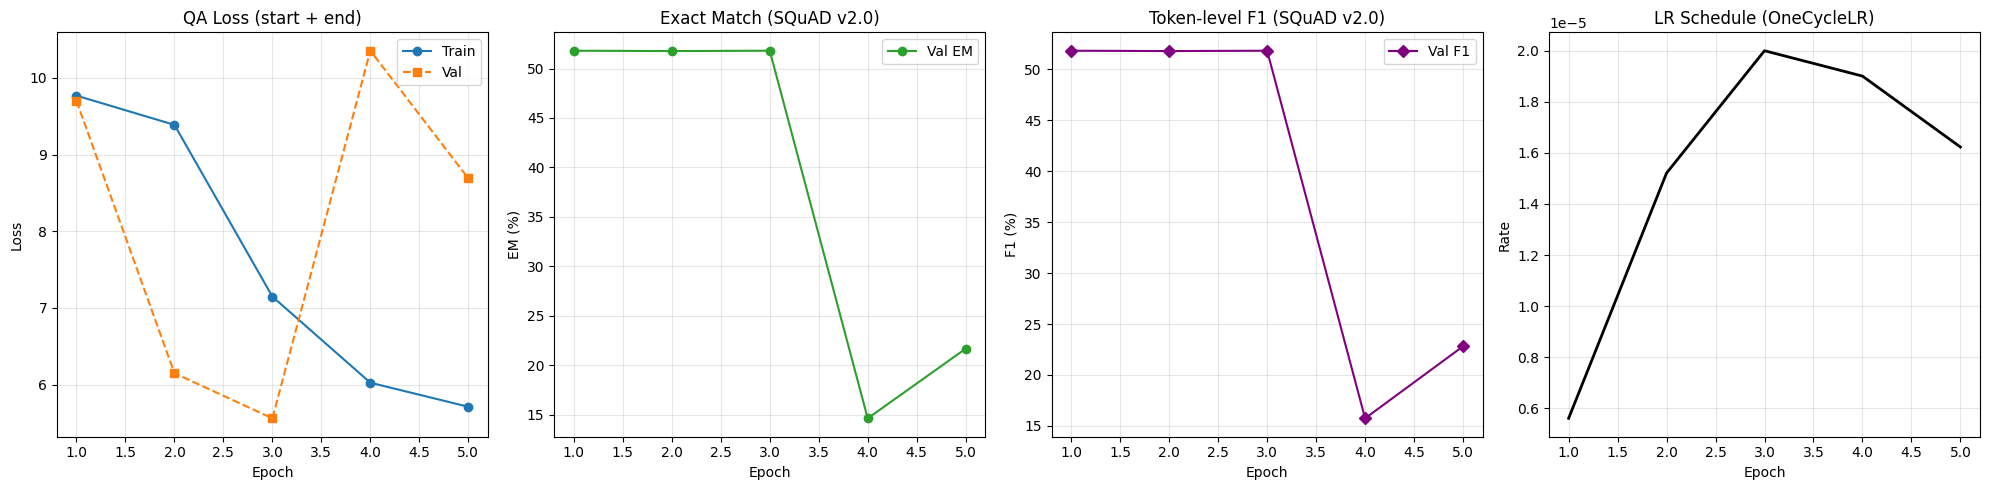

In [26]:
# ==========================================
# 4f. Plot Fine-tuning Curves
# ==========================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
epochs = range(1, len(qa_history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, qa_history['train_loss'], 'o-', label='Train', color='#1f77b4')
axes[0].plot(epochs, qa_history['val_loss'], 's--', label='Val', color='#ff7f0e')
axes[0].set_title('QA Loss (start + end)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Exact Match
axes[1].plot(epochs, [e*100 for e in qa_history['val_em']], 'o-', label='Val EM', color='#2ca02c')
axes[1].set_title('Exact Match (SQuAD v2.0)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('EM (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1
axes[2].plot(epochs, [f*100 for f in qa_history['val_f1']], 'D-', label='Val F1', color='purple')
axes[2].set_title('Token-level F1 (SQuAD v2.0)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# LR
axes[3].plot(epochs, qa_history['lrs'], label='LR', color='black', linewidth=2)
axes[3].set_title('LR Schedule (OneCycleLR)')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Rate')
axes[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
# 5. Final Evaluation & Audit

---


In [27]:
# ==========================================
# 5a. Full Validation Report
# ==========================================

val_em, val_f1, imp_acc = evaluate_qa_metrics(qa_model, squad_val_ds, DEVICE)

# Count answerable vs unanswerable
n_answerable = sum(1 for s in squad_val_ds.samples if not s['is_impossible'])
n_impossible = sum(1 for s in squad_val_ds.samples if s['is_impossible'])

print("=" * 65)
print("          FINAL SQuAD v2.0 VALIDATION AUDIT          ")
print("=" * 65)
print(f"  Dataset:              {len(squad_val_ds)} samples")
print(f"  Answerable:           {n_answerable}")
print(f"  Unanswerable:         {n_impossible}")
print("-" * 65)
print(f"  Exact Match (EM):     {val_em*100:.2f}%")
print(f"  Token F1:             {val_f1*100:.2f}%")
print(f"  No-Answer Accuracy:   {imp_acc*100:.2f}%")
print("=" * 65)


          FINAL SQuAD v2.0 VALIDATION AUDIT          
  Dataset:              2853 samples
  Answerable:           1375
  Unanswerable:         1478
-----------------------------------------------------------------
  Exact Match (EM):     51.81%
  Token F1:             51.81%
  No-Answer Accuracy:   100.00%


---

# 6. Qualitative QA Predictions

---


In [28]:
# ==========================================
# 6a. Single-Question Inference
# ==========================================

def answer_question(question, context, model, vocab, device, max_len=MAX_LEN, null_threshold=0.0):
    """Run QA inference on a single question-context pair."""
    model.eval()

    q_tokens = tokenizer(question)
    c_tokens = tokenizer(context)

    max_q = min(len(q_tokens), 64)
    max_c = max_len - max_q - 3
    q_tokens = q_tokens[:max_q]
    c_tokens = c_tokens[:max_c]

    q_ids = [vocab.get(t, UNK_IDX) for t in q_tokens]
    c_ids = [vocab.get(t, UNK_IDX) for t in c_tokens]

    input_ids = [CLS_IDX] + q_ids + [SEP_IDX] + c_ids + [SEP_IDX]
    segment_ids = [0] * (len(q_ids) + 2) + [1] * (len(c_ids) + 1)
    context_offset = len(q_ids) + 2

    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    segment_tensor = torch.tensor([segment_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        start_logits, end_logits = model(input_tensor, segment_tensor)

    start_logits = start_logits.squeeze(0)
    end_logits = end_logits.squeeze(0)

    # Null score
    null_score = start_logits[0].item() + end_logits[0].item()

    # Best span
    best_score = float('-inf')
    best_start, best_end = 0, 0
    seq_len = start_logits.size(0)

    for si in range(context_offset, seq_len):
        for ei in range(si, min(si + 30, seq_len)):
            score = start_logits[si].item() + end_logits[ei].item()
            if score > best_score:
                best_score = score
                best_start = si
                best_end = ei

    if null_score - null_threshold > best_score:
        return "[Unanswerable]", null_score - best_score

    tok_start = best_start - context_offset
    tok_end = best_end - context_offset
    if 0 <= tok_start < len(c_tokens) and 0 <= tok_end < len(c_tokens):
        answer = ' '.join(c_tokens[tok_start:tok_end + 1])
    else:
        answer = "[Out of range]"

    confidence = best_score - null_score
    return answer, confidence


In [29]:
# ==========================================
# 6b. Sample Predictions from Validation Set
# ==========================================

def show_qa_samples(dataset, model, vocab, device, n=10):
    """Show predictions on random samples from the dataset."""
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))

    print(f"{"#":<3} | {"TYPE":<8} | {"GOLD":<30} | {"PREDICTED":<30} | {"MATCH"}")
    print("-" * 110)

    for rank, idx in enumerate(indices, 1):
        s = dataset.samples[idx]
        pred_text, conf = answer_question(
            s['question'], s['context'], model, vocab, device
        )

        gold = s['gold_text'] if s['gold_text'] else '[Unanswerable]'
        q_type = 'NoAns' if s['is_impossible'] else 'Ans'

        em = compute_em(pred_text, gold if not s['is_impossible'] else '')
        match = 'Y' if em > 0 else ' '

        gold_disp = gold[:28] + '..' if len(gold) > 28 else gold
        pred_disp = pred_text[:28] + '..' if len(pred_text) > 28 else pred_text

        print(f"{rank:<3} | {q_type:<8} | {gold_disp:<30} | {pred_disp:<30} | {match}")

    print()

set_all_seeds(42)
show_qa_samples(squad_val_ds, qa_model, vocab, DEVICE, n=15)


#   | TYPE     | GOLD                           | PREDICTED                      | MATCH
--------------------------------------------------------------------------------------------------------------
1   | NoAns    | [Unanswerable]                 | [Unanswerable]                 |  
2   | NoAns    | [Unanswerable]                 | [Unanswerable]                 |  
3   | NoAns    | [Unanswerable]                 | [Unanswerable]                 |  
4   | Ans      | over 1,000                     | [Unanswerable]                 |  
5   | NoAns    | [Unanswerable]                 | [Unanswerable]                 |  
6   | NoAns    | [Unanswerable]                 | [Unanswerable]                 |  
7   | NoAns    | [Unanswerable]                 | [Unanswerable]                 |  
8   | NoAns    | [Unanswerable]                 | [Unanswerable]                 |  
9   | Ans      | Lexus                          | [Unanswerable]                 |  
10  | NoAns    | [Unanswerable]    

In [30]:
# ==========================================
# 6c. Custom Questions
# ==========================================

test_context = (
    "The Transformer architecture was introduced by Vaswani et al. in 2017. "
    "It relies entirely on self-attention mechanisms and does not use recurrence "
    "or convolutions. BERT, introduced by Devlin et al. in 2018, uses only the "
    "encoder part of the Transformer and is pre-trained with masked language "
    "modeling and next sentence prediction. BERT achieved state-of-the-art "
    "results on eleven natural language processing benchmarks including SQuAD."
)

test_questions = [
    "Who introduced the Transformer architecture?",
    "When was BERT introduced?",
    "What does BERT use for pre-training?",
    "Does the Transformer use recurrence?",
    "How many benchmarks did BERT achieve state-of-the-art results on?",
    "What is the capital of France?",  # Unanswerable from this context
]

print(f"Context: {test_context[:100]}...")
print()
print(f"{"Question":<55} | {"Answer":<30} | {"Confidence"}")
print("-" * 100)

for q in test_questions:
    answer, confidence = answer_question(q, test_context, qa_model, vocab, DEVICE)
    q_disp = q[:52] + "..." if len(q) > 52 else q
    a_disp = answer[:28] + ".." if len(answer) > 28 else answer
    print(f"{q_disp:<55} | {a_disp:<30} | {confidence:+.2f}")


Context: The Transformer architecture was introduced by Vaswani et al. in 2017. It relies entirely on self-at...

Question                                                | Answer                         | Confidence
----------------------------------------------------------------------------------------------------
Who introduced the Transformer architecture?            | [Unanswerable]                 | +0.00
When was BERT introduced?                               | [Unanswerable]                 | +0.00
What does BERT use for pre-training?                    | [Unanswerable]                 | +0.00
Does the Transformer use recurrence?                    | [Unanswerable]                 | +0.00
How many benchmarks did BERT achieve state-of-the-ar... | [Unanswerable]                 | +0.00
What is the capital of France?                          | [Unanswerable]                 | +0.00


---
# Summary

---

In this notebook, I implemented **BERT for Extractive Question Answering** from scratch,
building on the pre-trained BERT encoder from the previous notebook.

**Phase 1 (Pre-training):** The BERT encoder was pre-trained on WikiText-2 with MLM + NSP.

**Phase 2 (Fine-tuning):** The pre-trained encoder was fine-tuned on **SQuAD v2.0** for
extractive QA, predicting answer spans (start, end positions) within a context passage.
The model also handles **unanswerable questions** by predicting the `[CLS]` position.

**Key differences from SST-2 (classification):**

| Feature | SST-2 (Classification) | SQuAD v2.0 (Extractive QA) |
| :--- | :--- | :--- |
| **Input** | `[CLS] sentence [SEP]` | `[CLS] question [SEP] context [SEP]` |
| **Output head** | `[CLS]` → class logits | Every token → (start\_logit, end\_logit) |
| **Loss** | CrossEntropy on class | CrossEntropy on start + end positions |
| **Metrics** | Accuracy, F1 | **Exact Match, Token-level F1** |
| **Special case** | — | **Unanswerable** → predict position 0 |

### Architectural Evolution Path

| Step | Architecture | Key Innovation | Primary Task |
| :--- | :--- | :--- | :--- |
| 1 | Seq2Seq (LSTM/GRU) | Recurrent encoding | Translation |
| 2 | Seq2Seq + Attention | Dynamic alignment | Translation |
| 3 | **Transformer** | Self-Attention / Parallelism | Translation |
| 4 | **BERT → SST-2** | Bidirectional + Self-Supervised | **Classification** |
| 5 | **BERT → SQuAD** (this notebook) | Span prediction + No-answer | **Question Answering** |

---


In [31]:
%watermark -iv


datasets  : 4.8.3
matplotlib: 3.10.0
numpy     : 2.0.2
re        : 2.2.1
seaborn   : 0.13.2
sklearn   : 1.6.1
torch     : 2.10.0+cu128
torchinfo : 1.8.0

